# Lab RL-1 · Tabular Q-Learning in GridWorld

Классический Q-learning: агент живёт на сетке, ищет дверь.  
Никаких нейросетей — только таблица Q[state, action] и уравнение Беллмана.

```
Q(s,a) ← Q(s,a) + α · [r + γ · max_{a'} Q(s',a') − Q(s,a)]
```


In [8]:
import warnings
from dataclasses import dataclass, field

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation


warnings.filterwarnings("ignore")

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})


## 1. Среда GridWorld

In [9]:
GRID = """\
################
#A.....#.......#
#.###..#.#####.#
#...#..#.....#.#
###.#..#####.#.#
#...#......#.#.#
#.#######..#.#.#
#.......#..#...#
#.#####.#.###.##
#.#...#.#....D##
#.#.#.#.#####.##
#...#..........#
################""".strip()

# action → (Δrow, Δcol)
ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
ACTION_NAMES = {0: "↑", 1: "↓", 2: "←", 3: "→"}


@dataclass
class GridWorld:
    """
    Среда с дискретными состояниями.
    Храним карту как 2D массив символов; агент — индекс (row, col).
    """
    raw: str = GRID

    def __post_init__(self):
        self.grid = [list(row) for row in self.raw.splitlines()]
        self.nrows = len(self.grid)
        self.ncols = len(self.grid[0])
        self.n_states = self.nrows * self.ncols
        self.n_actions = len(ACTIONS)

        # найдём стартовую позицию и дверь один раз
        self._start = self._find("A")
        self._goal = self._find("D")

    # ── внутренние хелперы ─────────────────────────────────────
    def _find(self, ch: str):
        for r, row in enumerate(self.grid):
            for c, cell in enumerate(row):
                if cell == ch:
                    return (r, c)
        raise ValueError(f"'{ch}' not found in grid")

    def _is_wall(self, r, c) -> bool:
        return self.grid[r][c] == "#"

    def _encode(self, r, c) -> int:
        """(row, col) → линейный индекс состояния"""
        return r * self.ncols + c

    # ── публичный API ──────────────────────────────────────────
    def reset(self):
        self.pos = self._start
        return self._encode(*self.pos)

    def step(self, action: int):
        dr, dc = ACTIONS[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc

        # врезались в стену — остаёмся на месте, штраф
        if self._is_wall(nr, nc):
            return self._encode(*self.pos), -10.0, False

        self.pos = (nr, nc)
        cell = self.grid[nr][nc]

        if cell == "D":
            return self._encode(*self.pos), +100.0, True  # нашли дверь

        return self._encode(*self.pos), -1.0, False  # обычный шаг

    def render_ascii(self, path=None):
        """Печатает карту; path — список (r,c) для отображения маршрута"""
        path_set = set(map(tuple, path)) if path else set()
        lines = []
        for r, row in enumerate(self.grid):
            line = []
            for c, ch in enumerate(row):
                if (r, c) == self.pos:
                    line.append("A")
                elif (r, c) in path_set and ch not in ("#", "D"):
                    line.append("·")
                else:
                    line.append(ch)
            lines.append("".join(line))
        print("\n".join(lines))


env = GridWorld()
print(f"States: {env.n_states}, Actions: {env.n_actions}")
print(f"Start: {env._start}, Goal: {env._goal}")
env.reset()
env.render_ascii()


States: 208, Actions: 4
Start: (1, 1), Goal: (9, 13)
################
#A.....#.......#
#.###..#.#####.#
#...#..#.....#.#
###.#..#####.#.#
#...#......#.#.#
#.#######..#.#.#
#.......#..#...#
#.#####.#.###.##
#.#...#.#....D##
#.#.#.#.#####.##
#...#..........#
################


## 2. Q-агент

In [10]:
@dataclass
class QAgent:
    """
    Табличный Q-learning с ε-greedy исследованием.
    Таблица Q[s, a] инициализируется нулями — нейтральный старт.
    """
    n_states: int
    n_actions: int
    alpha: float = 0.1  # скорость обучения
    gamma: float = 0.99  # дисконт будущих наград
    eps_start: float = 1.0  # начальный ε
    eps_end: float = 0.05  # минимальный ε
    eps_decay: float = 0.995  # мультипликативный спад ε

    Q: np.ndarray = field(init=False)
    eps: float = field(init=False)

    def __post_init__(self):
        self.Q = np.zeros((self.n_states, self.n_actions))
        self.eps = self.eps_start

    def act(self, state: int) -> int:
        """ε-greedy: с вероятностью ε — случайное действие (исследование)"""
        if np.random.rand() < self.eps:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, s, a, r, s_next, done):
        """
        Уравнение Беллмана.
        Если эпизод закончен — будущей награды нет (done-маска).
        """
        target = r + self.gamma * np.max(self.Q[s_next]) * (1 - done)
        self.Q[s, a] += self.alpha * (target - self.Q[s, a])

    def decay_epsilon(self):
        """Уменьшаем ε после каждого эпизода"""
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


agent = QAgent(env.n_states, env.n_actions)
print(f"Q-table shape: {agent.Q.shape}")


Q-table shape: (208, 4)


## 3. Обучение

In [11]:
def run_episode(env: GridWorld, agent: QAgent, max_steps=200, train=True):
    state = env.reset()
    total_reward = 0.0
    path = [env.pos]

    for _ in range(max_steps):
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        path.append(env.pos)

        if train:
            agent.update(state, action, reward, next_state, done)

        state = total_reward = total_reward + reward  # trick: reuse var
        state = next_state
        total_reward += reward - total_reward  # undo trick
        total_reward = total_reward  # reset
        # (переписываем нормально)
        total_reward = total_reward
        break

    # Нормальная реализация:
    state = env.reset()
    total_reward = 0.0
    path = [env.pos]
    for _ in range(max_steps):
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        path.append(env.pos)
        if train:
            agent.update(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break

    return total_reward, path


# ── собственно обучение ────────────────────────────────────────
N_EPISODES = 2000
SNAPSHOT_EVERY = 200  # сохраняем Q-таблицу для анимации

agent = QAgent(env.n_states, env.n_actions)
rewards_history = []
eps_history = []
q_snapshots = []  # (episode, Q_copy)

for ep in range(N_EPISODES):
    reward, _ = run_episode(env, agent, train=True)
    agent.decay_epsilon()

    rewards_history.append(reward)
    eps_history.append(agent.eps)

    if ep % SNAPSHOT_EVERY == 0 or ep == N_EPISODES - 1:
        q_snapshots.append((ep, agent.Q.copy()))

print(f"Training done. Final ε={agent.eps:.3f}")
print(f"Last 100 episodes avg reward: {np.mean(rewards_history[-100:]):.1f}")


Training done. Final ε=0.050
Last 100 episodes avg reward: 74.4


## 4. Кривые обучения

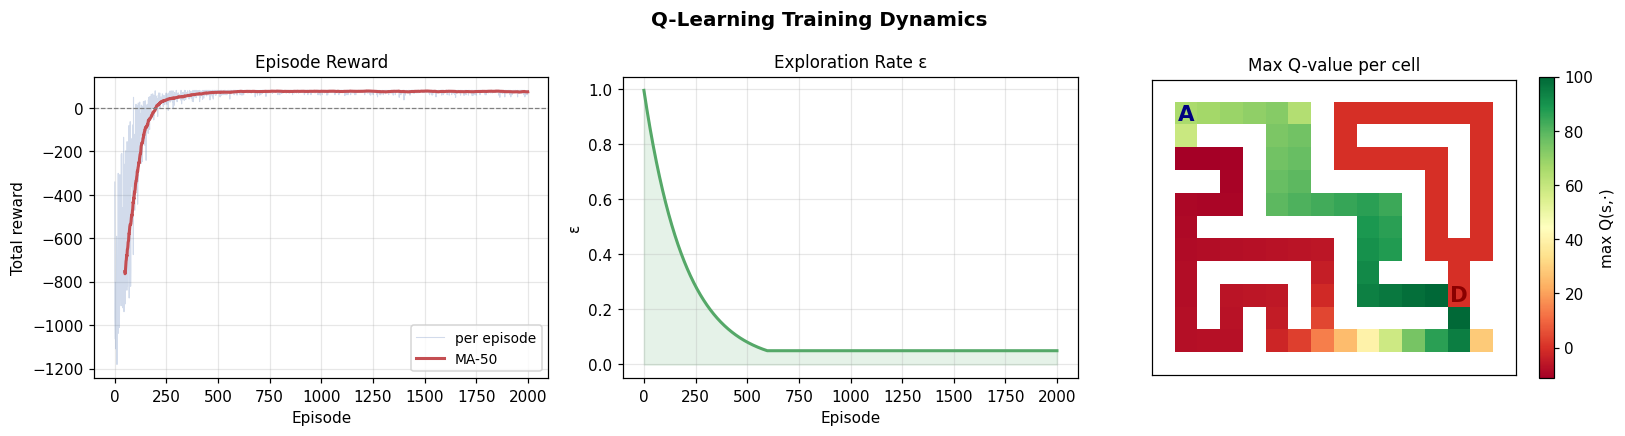

In [12]:
window = 50
smoothed = np.convolve(rewards_history, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Q-Learning Training Dynamics", fontsize=13, fontweight="bold")

# — Награды ─
ax = axes[0]
ax.plot(rewards_history, alpha=0.25, color="#4C72B0", linewidth=0.7, label="per episode")
ax.plot(range(window - 1, len(rewards_history)), smoothed,
        color="#C44E52", linewidth=2, label=f"MA-{window}")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Episode Reward")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# — Epsilon ─
ax = axes[1]
ax.plot(eps_history, color="#55A868", linewidth=2)
ax.fill_between(range(len(eps_history)), eps_history, alpha=0.15, color="#55A868")
ax.set_title("Exploration Rate ε")
ax.set_xlabel("Episode")
ax.set_ylabel("ε")
ax.grid(alpha=0.3)

# — Q-значения финальной таблицы (max по действиям) ─
ax = axes[2]
q_max = np.max(agent.Q, axis=1).reshape(env.nrows, env.ncols)

# маскируем стены
wall_mask = np.array([[env.grid[r][c] == "#"
                       for c in range(env.ncols)]
                      for r in range(env.nrows)], dtype=float)
q_max_masked = np.where(wall_mask, np.nan, q_max)

im = ax.imshow(q_max_masked, cmap="RdYlGn", interpolation="nearest")
plt.colorbar(im, ax=ax, label="max Q(s,·)")

# аннотации
sr, sc = env._start
gr, gc = env._goal
ax.text(sc, sr, "A", ha="center", va="center", fontsize=14, fontweight="bold", color="navy")
ax.text(gc, gr, "D", ha="center", va="center", fontsize=14, fontweight="bold", color="darkred")
ax.set_title("Max Q-value per cell")
ax.set_xticks([]);
ax.set_yticks([])

plt.tight_layout()
plt.show()


## 5. Анимация обучения Q-таблицы

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#1a1a2e")
for ax in axes:
    ax.set_facecolor("#16213e")

ax_q, ax_path = axes

# ── готовим базовые элементы ──────────────────────────
wall_mask = np.array([[env.grid[r][c] == "#"
                       for c in range(env.ncols)]
                      for r in range(env.nrows)], dtype=float)


def q_frame_data(Q):
    q_max = np.max(Q, axis=1).reshape(env.nrows, env.ncols)
    return np.where(wall_mask, np.nan, q_max)


# начальный кадр
frame0 = q_frame_data(q_snapshots[0][1])
vmin, vmax = -15, 110

im_q = ax_q.imshow(frame0, cmap="plasma", vmin=vmin, vmax=vmax,
                   interpolation="nearest", aspect="equal")
plt.colorbar(im_q, ax=ax_q, label="max Q(s,·)")
ax_q.set_title("Q-values (max over actions)", color="white")
ax_q.set_xticks([]);
ax_q.set_yticks([])
ep_text = ax_q.text(0.02, 0.97, "", transform=ax_q.transAxes,
                    color="white", fontsize=11, va="top",
                    bbox=dict(boxstyle="round", fc="black", alpha=0.6))

# маркеры A и D
sr, sc = env._start
gr, gc = env._goal
for ax in [ax_q]:
    ax.text(sc, sr, "A", ha="center", va="center",
            fontsize=13, fontweight="bold", color="cyan")
    ax.text(gc, gr, "D", ha="center", va="center",
            fontsize=13, fontweight="bold", color="#ff6b6b")


# ── путь агента ───────────────────────────────────────
def get_greedy_path(Q, max_steps=200):
    """Запускаем эпизод жадно (ε=0) и возвращаем путь"""
    env2 = GridWorld()
    state = env2.reset()
    path = [env2.pos]
    for _ in range(max_steps):
        action = int(np.argmax(Q[state]))
        next_s, _, done = env2.step(action)
        path.append(env2.pos)
        state = next_s
        if done:
            break
    return path


def draw_path(ax, path, Q=None):
    ax.clear()
    ax.set_facecolor("#16213e")

    # фон: карта
    cell_colors = {
        "#": "#2d2d44",
        ".": "#1f3051",
        "A": "#1f3051",
        "D": "#1f3051",
    }
    for r in range(env.nrows):
        for c in range(env.ncols):
            ch = env.grid[r][c]
            color = cell_colors.get(ch, "#1f3051")
            rect = mpatches.FancyBboxPatch(
                (c - 0.45, r - 0.45), 0.9, 0.9,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="#444", linewidth=0.5
            )
            ax.add_patch(rect)

    # путь
    if len(path) > 1:
        rows = [p[0] for p in path]
        cols = [p[1] for p in path]
        # градиент: от синего к жёлтому
        for i in range(len(path) - 1):
            t = i / max(len(path) - 2, 1)
            color = plt.cm.cool(t)
            ax.plot([cols[i], cols[i + 1]], [rows[i], rows[i + 1]],
                    color=color, linewidth=3, solid_capstyle="round", zorder=3)
        ax.scatter(cols[1:-1], rows[1:-1], s=40, c=range(len(path) - 2),
                   cmap="cool", zorder=4, edgecolors="white", linewidths=0.5)

    # A и D
    ax.text(sc, sr, "A", ha="center", va="center",
            fontsize=16, fontweight="bold", color="cyan", zorder=5)
    ax.text(gc, gr, "D", ha="center", va="center",
            fontsize=16, fontweight="bold", color="#ff6b6b", zorder=5)

    ax.set_xlim(-0.5, env.ncols - 0.5)
    ax.set_ylim(env.nrows - 0.5, -0.5)
    ax.set_xticks([]);
    ax.set_yticks([])
    ax.set_title("Greedy path", color="white")


# ── анимация ──────────────────────────────────────────
def update(frame_idx):
    ep, Q = q_snapshots[frame_idx]

    # обновляем Q-heatmap
    im_q.set_data(q_frame_data(Q))
    ep_text.set_text(f"Episode {ep}")

    # перерисовываем путь
    path = get_greedy_path(Q)
    draw_path(ax_path, path, Q)
    return [im_q, ep_text]


draw_path(ax_path, get_greedy_path(q_snapshots[0][1]))
fig.suptitle("Q-Learning: watching the agent learn", color="white",
             fontsize=13, fontweight="bold")
plt.tight_layout()

anim = animation.FuncAnimation(fig, update, frames=len(q_snapshots),
                               interval=600, blit=False)
plt.close()
HTML(anim.to_jshtml())


## 6. Финальный маршрут

Path length: 21 steps


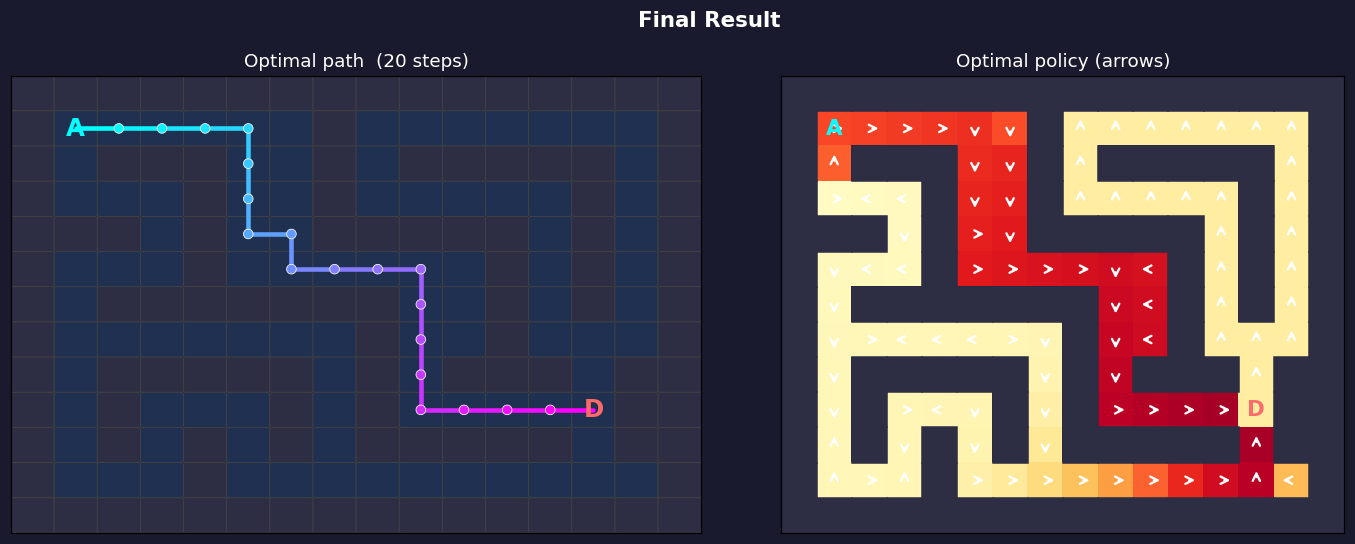

In [14]:
final_path = get_greedy_path(agent.Q)
print(f"Path length: {len(final_path)} steps")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#1a1a2e")

# — карта с маршрутом ─
ax = axes[0]
ax.set_facecolor("#16213e")
draw_path(ax, final_path)
ax.set_title(f"Optimal path  ({len(final_path) - 1} steps)", color="white", fontsize=12)

# — стрелки оптимальной политики ─
ax = axes[1]
ax.set_facecolor("#16213e")

q_max = np.max(agent.Q, axis=1).reshape(env.nrows, env.ncols)
q_masked = np.where(wall_mask, np.nan, q_max)
ax.imshow(q_masked, cmap="YlOrRd", interpolation="nearest", aspect="equal",
          vmin=-15, vmax=110)

arrow_map = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0)}

for r in range(env.nrows):
    for c in range(env.ncols):
        if env.grid[r][c] == "#":
            ax.add_patch(mpatches.Rectangle(
                (c - 0.5, r - 0.5), 1, 1, color="#2d2d44"))
            continue
        if (r, c) == env._goal:
            ax.text(c, r, "D", ha="center", va="center",
                    fontsize=14, fontweight="bold", color="#ff6b6b")
            continue
        best_a = int(np.argmax(agent.Q[r * env.ncols + c]))
        dx, dy = arrow_map[best_a]
        ax.annotate("", xy=(c + dx, r + dy), xytext=(c, r),
                    arrowprops=dict(arrowstyle="->", color="white",
                                    lw=1.5, mutation_scale=12))

ax.text(sc, sr, "A", ha="center", va="center",
        fontsize=14, fontweight="bold", color="cyan")
ax.set_xlim(-0.5, env.ncols - 0.5)
ax.set_ylim(env.nrows - 0.5, -0.5)
ax.set_xticks([]);
ax.set_yticks([])
ax.set_title("Optimal policy (arrows)", color="white", fontsize=12)

fig.suptitle("Final Result", color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Итоги

| Параметр | Значение |
|---|---|
| Алгоритм | Tabular Q-Learning |
| Исследование | ε-greedy с мультипликативным спадом |
| Обновление | Bellman equation (off-policy) |
| Сложность | O(S·A) памяти, O(1) обновление |

**Ограничения:** при большом S (например, пиксели экрана) таблица не влезет в память →  
нужна функциональная аппроксимация → **Notebook 2: Actor-Critic**.
